In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random
BIBD_7_3_1_DIFF_SET = [0, 1, 3] # v = 7, k = 3, lambda = 1
BIBD_91_10_1_DIFF_SET = [0, 1, 37, 39, 51, 58, 66, 69, 82, 86] # v = 91, k = 10, lambda = 1



In [16]:
def generate_bibd(n, k, steps, diff_set):
    bibd = np.zeros((n, steps), dtype=int)
    for i in range(n):
        for j in range(k):
            bibd[(i + diff_set[j]) % n][i] = 1
            
    for i in range(steps - n):
        x = bibd[:, i % n]
        bibd[:, n + i] = x
    return bibd

def TDMA(n, num_steps):
    tdma_matrix = np.zeros((n, num_steps), dtype=int)
    for i in range(num_steps):
        tdma_matrix[i % n][i] = 1
        tdma_matrix[(i + 1) % n][i] = 1
    return tdma_matrix

def random_schedules(n, num_steps, num_comms_per_step):
    schedules = np.zeros((n, num_steps), dtype=int)
    for i in range(num_steps):
        slots = list(range(n))
        for j in range(num_comms_per_step):
            steps = np.random.choice(slots)
            slots.remove(steps)
            schedules[steps][i] = 1
    return schedules

class agent:
    def __init__(self, id, is_leader, others, schedule):
        self.id = id
        self.schedule = schedule
        self.timestep = 0
        self.data = set([self.id])
        self.is_leader = is_leader
        self.others = others
        self.state = "not communicating"

    def receive_transmission(self, transmission, node):
        self.data.update(transmission)
        node.data.update(self.data)
    def turn(self, packet_loss_prob=0.3):
        self.state = "not communicating"
        if self.schedule is not None:
            group = np.where(self.schedule[:, self.timestep] == 1)[0]
            if self.id in group:
                for other in self.others:
                    if other.id in group and other.id != self.id and  random.random() > packet_loss_prob:
                    #print("data is", self.data)
                        other.receive_transmission(self.data, self)
            self.state = "communicating"
        self.timestep += 1


# main loop
def main(matrix, packet_loss_prob=0.3, shape_if_random=None):
    if matrix is None:
        matrix = random_schedules(shape_if_random[0], shape_if_random[1], num_comms_per_step=3)
    data_mat = np.zeros((matrix.shape[0], matrix.shape[1]), dtype=int)
    #setup
    matshape = matrix.shape
    v = matshape[0]
    trials = matshape[1]
    nodes = [agent(id = i, is_leader = i == 0, others = [], schedule = matrix) for i in range(v)]
    for i in range(v):
        nodes[i].others = [node for node in nodes if node.id != i]

    #running trials
    for t in range(trials):
        for node in nodes:
            node.turn(packet_loss_prob=packet_loss_prob)
            num_contacts = len(node.data)
            data_mat[node.id][t] = num_contacts
    return data_mat
    

def plot_comms(data_array, algorithm, file_path, packetloss):
    num_trials, num_nodes, T = data_array.shape

    # Style tweaks
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
    })

    fig, axes = plt.subplots(num_nodes, 1, figsize=(8, 14), sharex=True)

    fig.suptitle(f"Convergence of {algorithm} with {packetloss} Packet Loss", fontsize=16)

    for node in range(num_nodes):
        ax = axes[node]

        ax.set_yticks(range(1, num_nodes + 1))              
        ax.set_yticklabels(range(1, num_nodes + 1), fontsize=7)      
        for trial in range(num_trials):
            ax.plot(data_array[trial, node, :], alpha=0.4)
        
        ax.set_title(f"Node {node + 1}")
        ax.set_ylabel("Unique Packets", fontsize=13)
        
        # Clean look
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(alpha=0.2)
        ax.set_xticks(range(0, T, 1))  # Show x-ticks every 5 steps
        ax.set_xticklabels(range(0, T, 1))
    axes[-1].set_xlabel("Time")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(file_path) if file_path else plt.show()



def packetloss_sweep(schedule, algorithm, iters, packetloss, file_path = None):
    results = np.zeros((len(packetloss), iters), dtype=int)
    for i in packetloss:
        for j in range(iters):
            print(f"Running {algorithm} with packet loss {i} - Iteration {j + 1}/{iters}")
            # run iter. 
            if len(schedule) == 3: # if schedule is a tuple of (n, steps, comms_per_step), generate random schedule on the fly for each iteration
                data_mat = main(random_schedules(schedule[0], schedule[1], num_comms_per_step=schedule[2]), packet_loss_prob=i)
                shape = (schedule[0], schedule[1])
            else:
                data_mat = main(schedule, packet_loss_prob=i)
                shape = schedule.shape
            data_avg = np.mean(data_mat, axis=0)
            time_to_converge = np.where(data_avg >= shape[0])  # first time all nodes have all packets
            results[packetloss.index(i)][j] = time_to_converge[0][0] if len(time_to_converge[0]) > 0 else -1  # -1 if never converged
    avg_results = np.mean(results, axis=1)

    packetloss_arr = np.array(packetloss)

    # Flatten results for scatter
    x_scatter = np.repeat(packetloss_arr, results.shape[1])
    y_scatter = results.flatten()

    # Remove failed runs (-1)
    mask = y_scatter != -1
    x_scatter = x_scatter[mask]
    y_scatter = y_scatter[mask]

    # --- Plot ---
    plt.figure(figsize=(8, 5))

    # Scatter: all trials
    plt.scatter(
        x_scatter,
        y_scatter,
        alpha=0.4,
        s=20,
        label="Trials"
    )

    # Line: average
    plt.plot(
        packetloss_arr,
        avg_results,
        linewidth=2.5,
        label="Average"
    )

    # Labels + title
    plt.xlabel("Packet Loss Probability")
    plt.ylabel("Time to Converge")
    plt.title(f"Convergence vs Packet Loss of {algorithm}")

    # Clean styling
    plt.grid(alpha=0.2)
    plt.legend()

    # Remove top/right borders (pro look)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(file_path) if file_path else plt.show()

    return avg_results, results


    









7 3 1:  (10, 7, 20)
7 node tdma:  (10, 7, 20)
[]
7 random schedule:  (10, 7, 20)


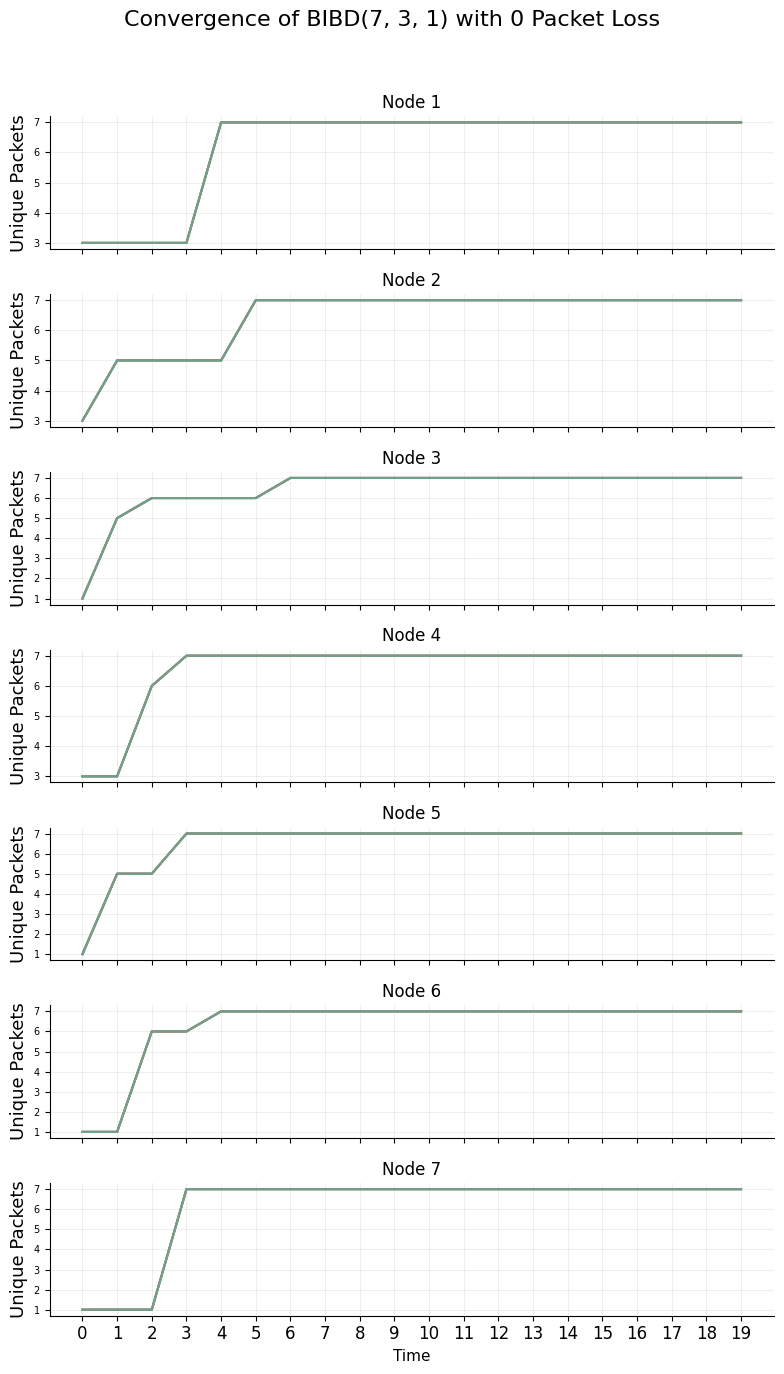

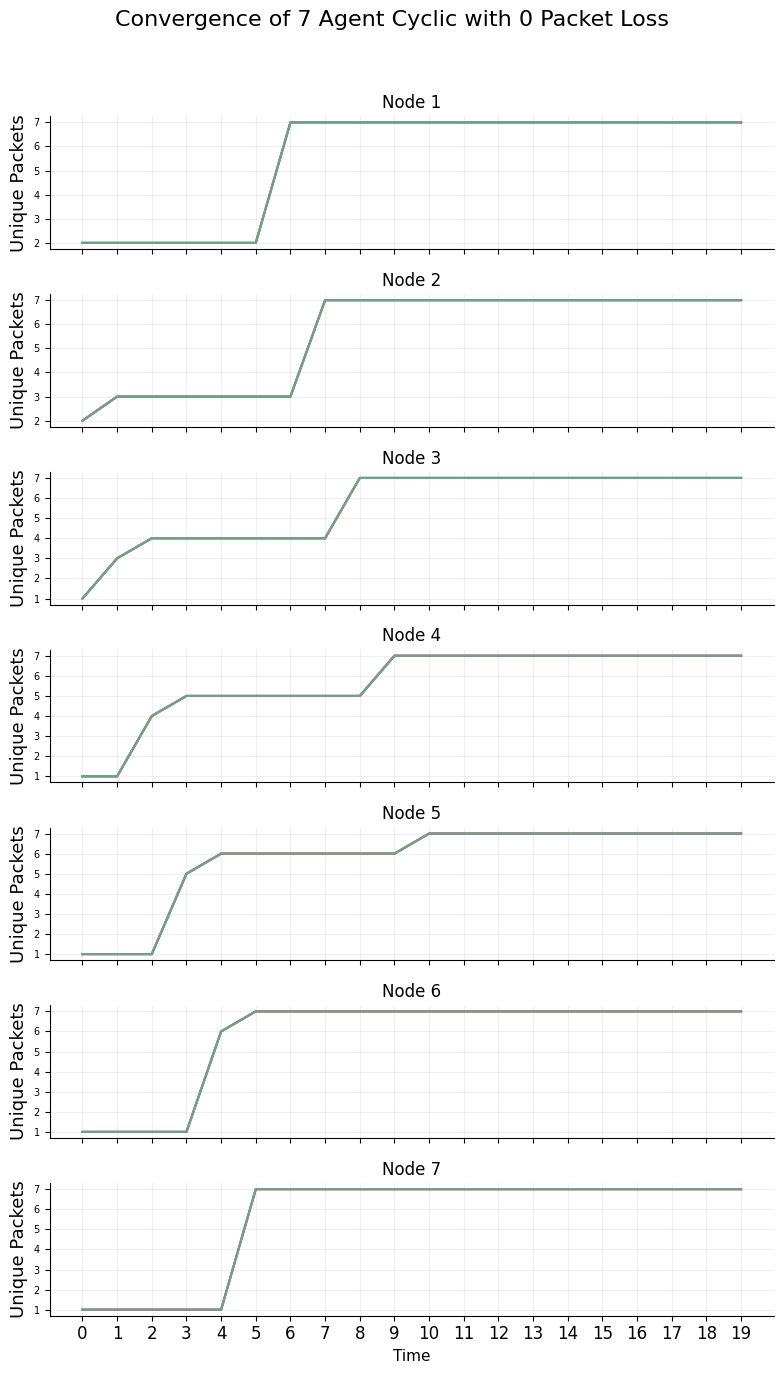

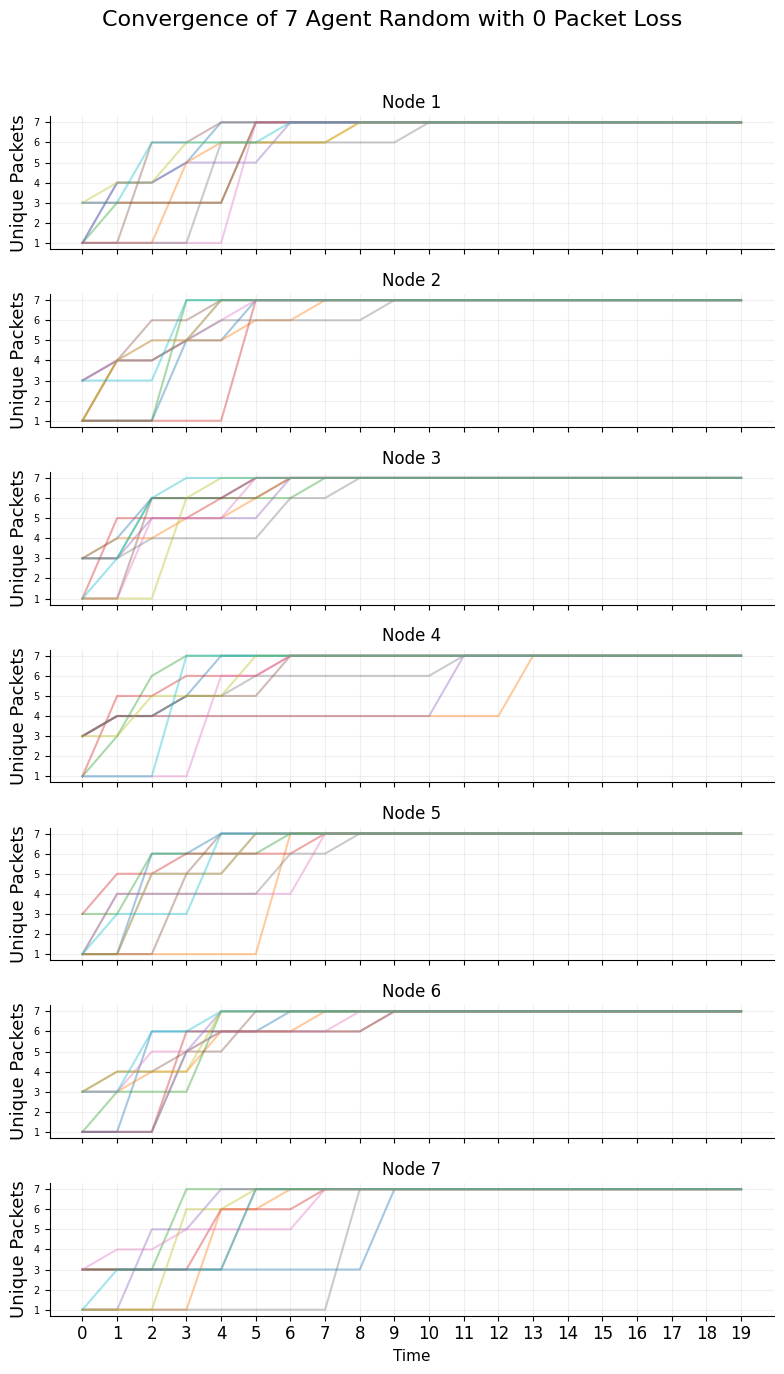

In [17]:
bibd_7_3_1 = generate_bibd(7, 3, 20, BIBD_7_3_1_DIFF_SET)
#bibd_91_10_1 = generate_bibd(91, 10, BIBD_91_10_1_DIFF_SET[0])
random_sched = random_schedules(7, 20, num_comms_per_step=2)
dataensamble_7_3_1 = []

for i in range(10):
     dataensamble_7_3_1.append(main(bibd_7_3_1, packet_loss_prob=0))
print("7 3 1: ",np.array(dataensamble_7_3_1).shape)
plot_comms(np.array(dataensamble_7_3_1), "BIBD(7, 3, 1)", file_path="images/7_3_1_convergence_agents.png", packetloss=0)
dataensamble_7_tdma = []
for i in range(10):
     dataensamble_7_tdma.append(main(TDMA(7, 20), packet_loss_prob=0))
print("7 node tdma: ",np.array(dataensamble_7_tdma).shape)
dataensamble_7_random = []
plot_comms(np.array(dataensamble_7_tdma), "7 Agent Cyclic", file_path="images/7_tdma_schedule_convergence_agents.png", packetloss=0)
print(dataensamble_7_random)
for i in range(10):
     dataensamble_7_random.append(main(None, packet_loss_prob=0, shape_if_random=(7, 20)))
print("7 random schedule: ",np.array(dataensamble_7_random).shape)
plot_comms(np.array(dataensamble_7_random), "7 Agent Random", file_path="images/7_random_schedule_convergence_agents.png", packetloss=0)

Running Random with packet loss 0 - Iteration 1/2
Running Random with packet loss 0 - Iteration 2/2
Running Random with packet loss 0.1 - Iteration 1/2
Running Random with packet loss 0.1 - Iteration 2/2
Running BIBD(7, 3, 1) with packet loss 0 - Iteration 1/2
Running BIBD(7, 3, 1) with packet loss 0 - Iteration 2/2
Running BIBD(7, 3, 1) with packet loss 0.1 - Iteration 1/2
Running BIBD(7, 3, 1) with packet loss 0.1 - Iteration 2/2
Running Cyclic with packet loss 0 - Iteration 1/2
Running Cyclic with packet loss 0 - Iteration 2/2
Running Cyclic with packet loss 0.1 - Iteration 1/2
Running Cyclic with packet loss 0.1 - Iteration 2/2
BIBD(7, 3, 1) avg convergence times: [6. 6.]
Random Schedule avg convergence times: [ 6. 11.]
Cyclic Schedule avg convergence times: [10. 10.]
BIBD(7, 3, 1) standard deviation of all convergence times: [0. 0.]
Random Schedule standard deviation of all convergence times: [1. 2.]
Cyclic Schedule standard deviation of all convergence times: [0. 0.]


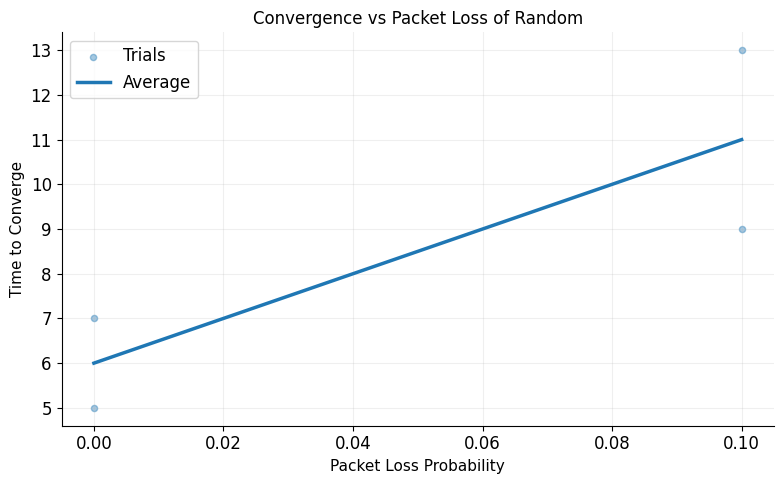

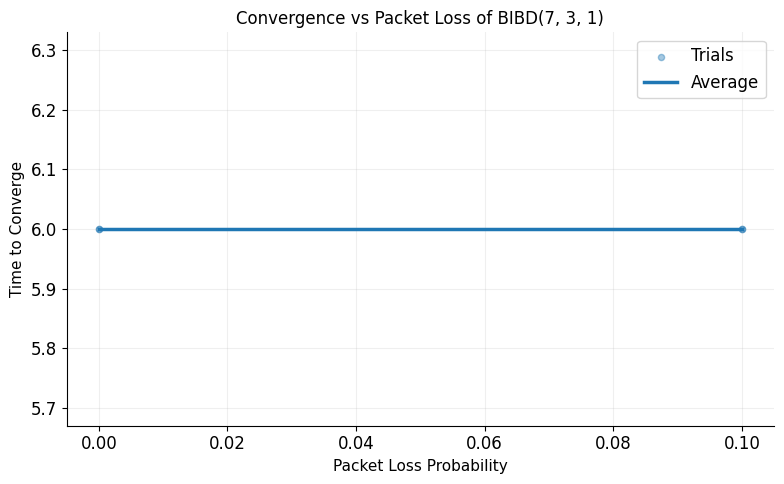

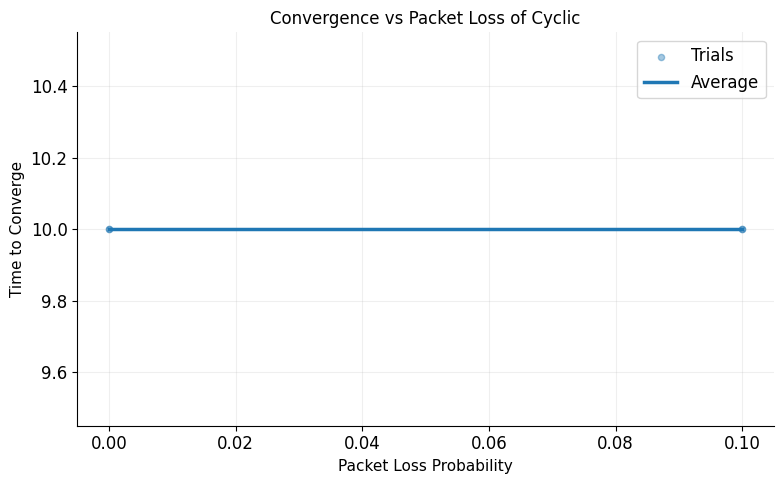

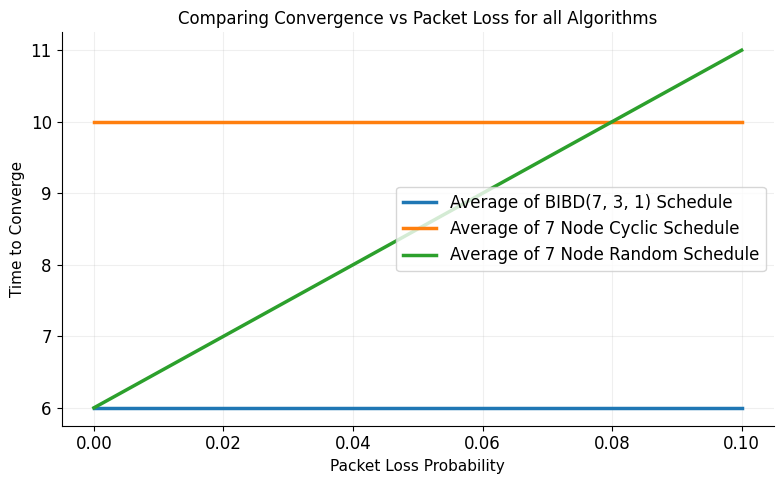

In [ ]:
packetloss = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
packetloss_arr = np.array(packetloss)
iters = 20
bibd_7_3_1 = generate_bibd(7, 3, 400, BIBD_7_3_1_DIFF_SET)
tdma_sched = TDMA(7, 400)
avg_results_random, results_random = packetloss_sweep((7,400,3), "Random", iters, packetloss, file_path="images/random_schedule_7_packetloss.png")
avg_results_bibd, results_bibd = packetloss_sweep(bibd_7_3_1, "BIBD(7, 3, 1)", iters, packetloss, file_path="images/7_3_1_packetloss.png")

avg_results_tdma, results_tdma = packetloss_sweep(tdma_sched, "Cyclic", iters, packetloss, file_path="images/tdma_7_packetloss.png")
print("BIBD(7, 3, 1) avg convergence times:", avg_results_bibd)
print("Random Schedule avg convergence times:", avg_results_random) 
print("Cyclic Schedule avg convergence times:", avg_results_tdma)
print("BIBD(7, 3, 1) standard deviation of all convergence times:", np.std(results_bibd, axis=1))
print("Random Schedule standard deviation of all convergence times:", np.std(results_random, axis=1))
print("Cyclic Schedule standard deviation of all convergence times:", np.std(results_tdma, axis=1))

plt.figure(figsize=(8, 5))

plt.plot(
    packetloss_arr,
    avg_results_bibd,
    linewidth=2.5,
    label="Average of BIBD(7, 3, 1) Schedule"
)
plt.plot(
    packetloss_arr,
    avg_results_tdma,
    linewidth=2.5,
    label="Average of 7 Node Cyclic Schedule"
)
plt.plot(
    packetloss_arr,
    avg_results_random,
    linewidth=2.5,
    label="Average of 7 Node Random Schedule"
)

# Labels + title
plt.xlabel("Packet Loss Probability")
plt.ylabel("Time to Converge")
plt.title(f"Comparing Convergence vs Packet Loss for all Algorithms")

# Clean styling
plt.grid(alpha=0.2)
plt.legend()

# Remove top/right borders (pro look)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
file_path = "images/comparison_7_packetloss.png"
plt.tight_layout()
plt.savefig(file_path) if file_path else plt.show()




In [21]:
print(np.mean((avg_results_bibd - avg_results_random)/avg_results_random))
print(np.mean((avg_results_bibd - avg_results_tdma)/avg_results_tdma))

-0.22727272727272727
-0.4


Running 91 Node Cyclic with packet loss 0 - Iteration 1/1
Running 91 Node Cyclic with packet loss 0.1 - Iteration 1/1
Cyclic Schedule avg convergence times: [178. 178.]
Cyclic Schedule standard deviation of all convergence times: [0. 0.]


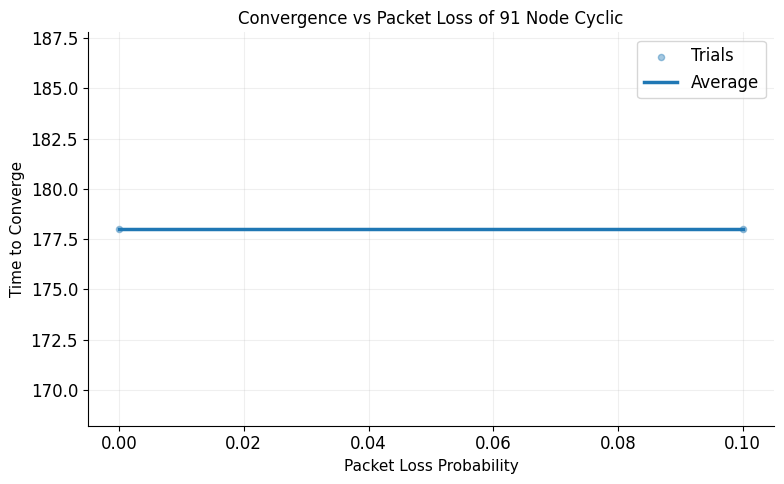

In [ ]:
iters = 20
bibd_91_10_1 = generate_bibd(91, 10, 200, BIBD_91_10_1_DIFF_SET)
random_91_sched = random_schedules(91, 2000, num_comms_per_step=10)
tdma_91_sched = TDMA(91, 4000)
# avg_results_random, results_random = packetloss_sweep((91, 500, 10), "91 Node Random", iters, packetloss, file_path="images/random_schedule_91_packetloss.png")
# avg_results_bibd, results_bibd = packetloss_sweep(bibd_91_10_1, "BIBD(91, 10, 1)", iters, packetloss, file_path="images/91_10_1_packetloss.png")
avg_results_tdma, results_tdma = packetloss_sweep(tdma_91_sched, "91 Node Cyclic", iters, packetloss, file_path="images/tdma_91_packetloss.png")

# print("BIBD(7, 3, 1) avg convergence times:", avg_results_bibd)
# print("Random Schedule avg convergence times:", avg_results_random) 
print("Cyclic Schedule avg convergence times:", avg_results_tdma)
# print("BIBD(7, 3, 1) standard deviation of all convergence times:", np.std(results_bibd, axis=1))
# print("Random Schedule standard deviation of all convergence times:", np.std(results_random, axis=1))
print("Cyclic Schedule standard deviation of all convergence times:", np.std(results_tdma, axis=1))


Scatter shapes: (120,) (120,)
[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1 0.1 0.1 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
 0.2 0.2 0.2 0.2 0.2 0.2 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4
 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


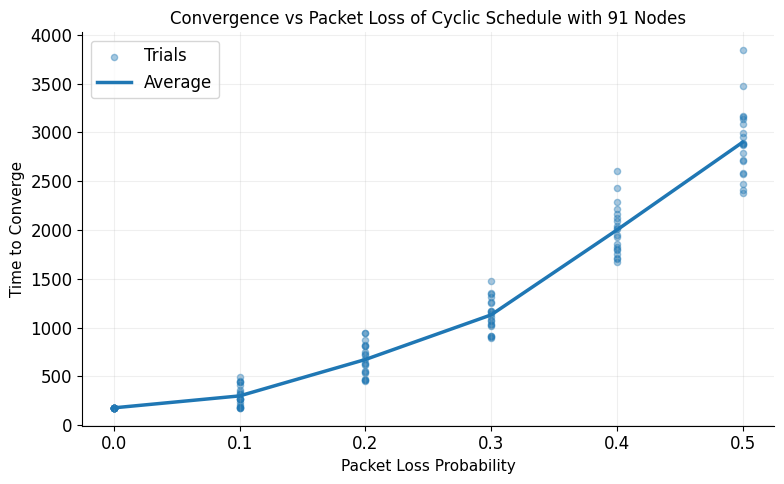

In [ ]:

results_tdma_trim = results_tdma[0:6, :]
x_scatter = np.repeat(packetloss_arr[0:6], results_tdma.shape[1])
y_scatter = results_tdma_trim.flatten()
print("Scatter shapes:", x_scatter.shape, y_scatter.shape)
print(x_scatter)
# --- Plot ---
plt.figure(figsize=(8, 5))

# Scatter: all trials
plt.scatter(
    x_scatter,
    y_scatter,
    alpha=0.4,
    s=20,
    label="Trials"
)

# Line: average
plt.plot(
    packetloss_arr[0:6],
    avg_results_tdma[0:6],
    linewidth=2.5,
    label="Average"
)

# Labels + title
plt.xlabel("Packet Loss Probability")
plt.ylabel("Time to Converge")
plt.title(f"Convergence vs Packet Loss of Cyclic Schedule with 91 Nodes")

# Clean styling
plt.grid(alpha=0.2)
plt.legend()

# Remove top/right borders (pro look)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
file_path = "images/tdma_91_packetloss.png"
plt.savefig(file_path) if file_path else plt.show()


In [ ]:



# --- Plot ---
plt.figure(figsize=(8, 5))

# Line: average
plt.plot(
    packetloss_arr,
    avg_results_bibd,
    linewidth=2.5,
    label="Average of BIBD(91, 10, 1)"
)
plt.plot(
    packetloss_arr,
    avg_results_tdma,
    linewidth=2.5,
    label="Average of 91 Node Cyclic Schedule"
)
plt.plot(
    packetloss_arr,
    avg_results_random,
    linewidth=2.5,
    label="Average of 91 Node Random Schedule"
)

# Labels + title
plt.xlabel("Packet Loss Probability")
plt.ylabel("Time to Converge")
plt.title(f"Comparing Convergence vs Packet Loss for all Algorithms")

# Clean styling
plt.grid(alpha=0.2)
plt.legend()

# Remove top/right borders (pro look)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
file_path = "images/comparison_91_packetloss.png"
plt.tight_layout()
plt.savefig(file_path) if file_path else plt.show()

In [ ]:
print(np.mean((avg_results_bibd - avg_results_random)/avg_results_random))
print(np.mean((avg_results_bibd[0:6] - avg_results_tdma[0:6])/avg_results_tdma[0:6]))

-0.19617525634925664
-0.8580853996017459
